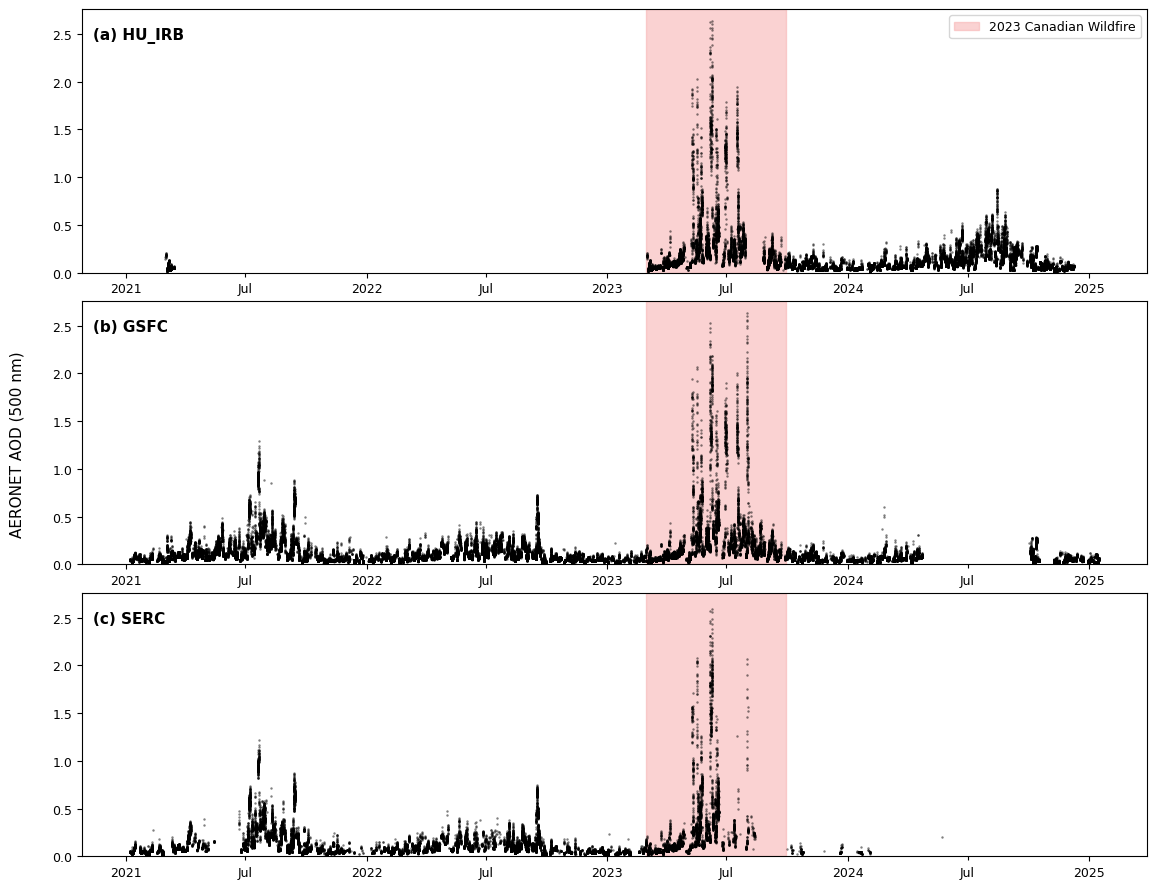

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

stations = ["HU_IRB", "GSFC", "SERC"]
labels   = [f"({chr(97+i)})" for i in range(len(stations))]

highlight_start = pd.Timestamp("2023-03-01")
highlight_end   = pd.Timestamp("2023-09-30")

fig, axes = plt.subplots(len(stations), 1, figsize=(12, 9), sharex=True,sharey=True)
if len(stations) == 1:
    axes = [axes]

for ax, station, label in zip(axes, stations, labels):
    df = pd.read_csv(f"../data/{station}_AOD500_preprocessed.csv", parse_dates=["datetime"])
    df = df.dropna(subset=["AOD_500nm"]).sort_values("datetime")
    df = df[df["datetime"].dt.year.between(2021, 2025)]

    ax.axvspan(highlight_start, highlight_end,
               color="#f8b4b4", alpha=0.6, zorder=0, label="2023 Canadian Wildfire")

    ax.scatter(df["datetime"], df["AOD_500nm"],
               s=3, color="black", alpha=0.5, linewidths=0, zorder=2)

    ax.text(0.01, 0.93, f"{label} {station}", transform=ax.transAxes,
            fontsize=11, fontweight="bold", va="top")

    ax.set_ylim(bottom=0)
    ax.tick_params(labelsize=9)

    if ax == axes[0]:
        ax.legend(loc="upper right", fontsize=9, frameon=True, framealpha=0.8)

# Shared Y-axis label
fig.text(0.04, 0.5, "AERONET AOD (500 nm)", va="center", rotation="vertical", fontsize=11)

# X-axis: Jan (year label, full tick) + Jul (minor-style tick) on ALL subplots
def custom_fmt(x, pos=None):
    dt = mdates.num2date(x)
    return str(dt.year) if dt.month == 1 else "Jul"

for ax in axes:
    ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))
    ax.xaxis.set_major_formatter(plt.FuncFormatter(custom_fmt))
    # plt.setp(ax.get_xticklabels(), visible=True)
    ax.tick_params(axis="x", which="major", labelsize=9, labelbottom=True)  # <-- key fix
    fig.canvas.draw()
    for tick in ax.xaxis.get_major_ticks():
        if tick.label1.get_text() == "Jul":
            tick.tick1line.set_markersize(3)
            tick.tick2line.set_markersize(3)
            tick.label1.set_fontsize(8)
            # tick.label1.set_color("gray")
    ax.tick_params(axis="x", which="major", labelsize=9)

plt.tight_layout(h_pad=0.4)
plt.subplots_adjust(left=0.1)
plt.savefig("../data/AERONET_AOD_time_series.png", dpi=300, bbox_inches="tight")
plt.show()
